# Sentiment Analysis of Product Reviews
## Summer Internship Project

This project classifies product reviews as **Positive** or **Negative** using Natural Language Processing (NLP) and machine learning.

### Main Steps
- Text cleaning
- Tokenization
- Stopword removal
- Lemmatization
- TF-IDF feature extraction
- Naive Bayes classification
- Logistic Regression classification
- Linear SVM classification
- Model comparison
- Classification report
- Confusion matrix
- Prediction on new reviews

### Dataset
A public labeled product-review dataset is used. The project selects **250 Positive** and **250 Negative** reviews before duplicate removal. After removing duplicate records, the final dataset contains **498 reviews**.


In [16]:
import pandas as pd
import re
import nltk
import urllib.request
import zipfile
import os
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to C:\Users\Shrey
[nltk_data]     Tiwari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Shrey
[nltk_data]     Tiwari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Shrey
[nltk_data]     Tiwari\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Shrey
[nltk_data]     Tiwari\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 1. Load Dataset

In [18]:
# Download and load the public labeled review dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00331/sentiment%20labelled%20sentences.zip"
zip_file = "sentiment_dataset.zip"
data_file = "reviews_dataset.csv"

if not os.path.exists(data_file):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_file)

    with zipfile.ZipFile(zip_file, "r") as z:
        review_files = [name for name in z.namelist() if name.endswith("_cells_labelled.txt")]

        if not review_files:
            raise FileNotFoundError("Review dataset file not found.")

        with z.open(review_files[0]) as f:
            full_df = pd.read_csv(f, sep="\t", header=None, names=["Review", "Label"])

    positive_reviews = full_df[full_df["Label"] == 1].head(250)
    negative_reviews = full_df[full_df["Label"] == 0].head(250)
    df = pd.concat([positive_reviews, negative_reviews], ignore_index=True)

    df["Sentiment"] = df["Label"].map({1: "Positive", 0: "Negative"})
    df = df[["Review", "Sentiment"]]
    df.to_csv(data_file, index=False)
    os.remove(zip_file)
else:
    df = pd.read_csv(data_file)

print("Dataset Shape:", df.shape)
print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())
    
print("\nFirst 5 Reviews:")
print(df.head())


Dataset Shape: (500, 2)

Sentiment Distribution:
Sentiment
Positive    250
Negative    250
Name: count, dtype: int64

First 5 Reviews:
                                        Review Sentiment
0                  Good case, Excellent value.  Positive
1                       Great for the jawbone.  Positive
2                            The mic is great.  Positive
3  If you are Razr owner...you must have this!  Positive
4              And the sound quality is great.  Positive


## 2. Check Dataset

In [19]:
print('Dataset Shape:', df.shape)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nDuplicate Records:', df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print('Final Dataset Shape:', df.shape)

print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())

Dataset Shape: (500, 2)

Missing Values:
Review       0
Sentiment    0
dtype: int64

Duplicate Records: 2
Final Dataset Shape: (498, 2)

Sentiment Distribution:
Sentiment
Negative    250
Positive    248
Name: count, dtype: int64


## 3. Text Cleaning


In [20]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["Clean_Review"] = df["Review"].apply(clean_text)

print(df[["Review", "Clean_Review"]].head())

                                        Review  \
0                  Good case, Excellent value.   
1                       Great for the jawbone.   
2                            The mic is great.   
3  If you are Razr owner...you must have this!   
4              And the sound quality is great.   

                               Clean_Review  
0                 good case excellent value  
1                     great for the jawbone  
2                          the mic is great  
3  if you are razr owner you must have this  
4            and the sound quality is great  


## 4. Tokenization, Stopword Removal and Lemmatization


In [21]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("never")

lemmatizer = WordNetLemmatizer()


def process_text(text):
    
    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(words)

df["Processed_Review"] = df["Clean_Review"].apply(process_text)

print(df[["Review", "Processed_Review"]].head())

                                        Review           Processed_Review
0                  Good case, Excellent value.  good case excellent value
1                       Great for the jawbone.              great jawbone
2                            The mic is great.                  mic great
3  If you are Razr owner...you must have this!            razr owner must
4              And the sound quality is great.        sound quality great


[nltk_data] Downloading package punkt to C:\Users\Shrey
[nltk_data]     Tiwari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Shrey
[nltk_data]     Tiwari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Shrey
[nltk_data]     Tiwari\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Shrey
[nltk_data]     Tiwari\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 5. Train-Test Split and TF-IDF


In [22]:
X = df["Processed_Review"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training samples: 398
Testing samples: 100
Training TF-IDF shape: (398, 2324)
Testing TF-IDF shape: (100, 2324)


## 6. Naive Bayes


In [23]:
nb = MultinomialNB(alpha=0.1)

nb.fit(X_train_tfidf, y_train)

prediction_nb = nb.predict(X_test_tfidf)

accuracy_nb = accuracy_score(y_test, prediction_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.74


## 7. Logistic Regression


In [24]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train_tfidf, y_train)

prediction_lr = lr.predict(X_test_tfidf)

accuracy_lr = accuracy_score(y_test, prediction_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.77


## 8. Linear SVM


In [25]:
svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train_tfidf, y_train)

prediction_svm = svm.predict(X_test_tfidf)

accuracy_svm = accuracy_score(y_test, prediction_svm)

print("Linear SVM Accuracy:", accuracy_svm)

Linear SVM Accuracy: 0.8


## 9. Model Comparison


                 Model  Accuracy
0          Naive Bayes      0.74
1  Logistic Regression      0.77
2           Linear SVM      0.80


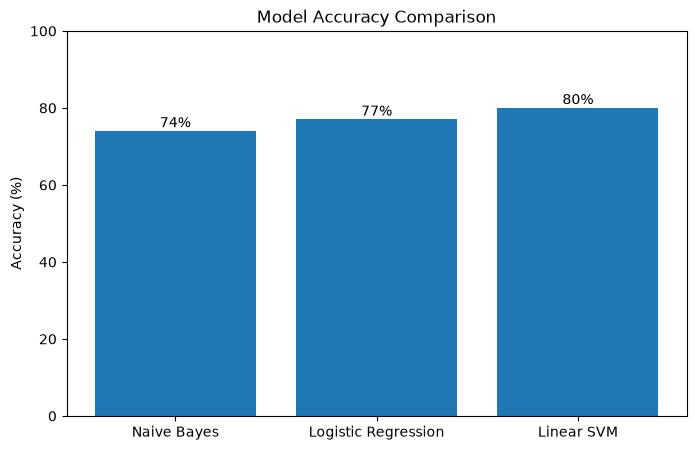

In [26]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_lr,
        accuracy_svm
    ]
})

print(results)

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Accuracy"] * 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

for i, value in enumerate(results["Accuracy"] * 100):
    plt.text(i, value + 1, f"{value:.0f}%", ha="center")

plt.show()

## 10. Classification Report


In [27]:
print("Classification Report - Linear SVM")
print()

print(classification_report(
    y_test,
    prediction_svm
))

Classification Report - Linear SVM

              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80        50
    Positive       0.80      0.80      0.80        50

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100



## 11. Confusion Matrix

Confusion Matrix - Linear SVM
[[40 10]
 [10 40]]


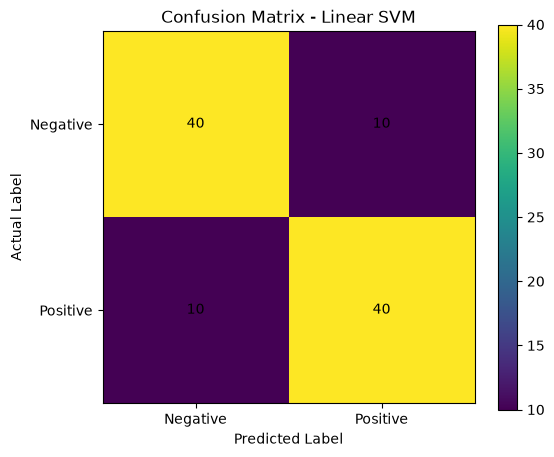

In [28]:
cm = confusion_matrix(y_test, prediction_svm, labels=["Negative", "Positive"])

print("Confusion Matrix - Linear SVM")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 12. Predict a New Review

In [29]:
def prepare_review(review):
    review = clean_text(review)
    review = process_text(review)
    return tfidf.transform([review])


def predict_sentiment(review):
    processed_review = prepare_review(review)

    nb_result = nb.predict(processed_review)[0]
    lr_result = lr.predict(processed_review)[0]
    svm_result = svm.predict(processed_review)[0]

    print("Review:", review)
    print("Naive Bayes:", nb_result)
    print("Logistic Regression:", lr_result)
    print("Linear SVM:", svm_result)


print("Test 1:")
predict_sentiment(
    "The product is excellent and works perfectly"
)


print("\nTest 2:")
predict_sentiment(
    "The product is terrible and does not work"
)

print("\nTest 3:")
predict_sentiment(
    "I am very happy with this product"
)

print("\nTest 4:")
predict_sentiment(
    "I am disappointed with the quality"
)

Test 1:
Review: The product is excellent and works perfectly
Naive Bayes: Positive
Logistic Regression: Positive
Linear SVM: Positive

Test 2:
Review: The product is terrible and does not work
Naive Bayes: Negative
Logistic Regression: Negative
Linear SVM: Negative

Test 3:
Review: I am very happy with this product
Naive Bayes: Positive
Logistic Regression: Positive
Linear SVM: Positive

Test 4:
Review: I am disappointed with the quality
Naive Bayes: Negative
Logistic Regression: Negative
Linear SVM: Negative


## Conclusion

This project demonstrates a complete NLP pipeline for classifying product reviews as **Positive** or **Negative**.

The project performs text cleaning, tokenization, stopword removal, lemmatization, TF-IDF feature extraction, model training and evaluation.

### Dataset Summary
- Initial reviews: **500**
- Positive reviews before duplicate removal: **250**
- Negative reviews before duplicate removal: **250**
- Final reviews after duplicate removal: **498**

### Final Model Results
| Model | Accuracy |
|---|---:|
| Naive Bayes | 74% |
| Logistic Regression | 77% |
| **Linear SVM** | **80%** |

Linear SVM is the best-performing model in this experiment, with **80% accuracy**. Its precision, recall and F1-score are also **0.80** for both Positive and Negative classes.

The project shows how traditional machine-learning models can be combined with NLP techniques to perform sentiment classification on review text.
